# Experiment: Uncertainty Quatification

In [1]:
import sys
import os
project_root = "" # set the root path
sys.path.insert(0, project_root)

import h5py
import torch
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from functions.helper import batch_wise_random_drop, obs_field_reconstruction, sampler_test_data_generator, sampler_checkpoint_load, sampler_training_visualizer
device = [i for i in range(torch.cuda.device_count())][0]

In [2]:
secnario = "SHM"

In [3]:
obs_sample = [4096, 256, 64, 32, 16, 12]
test_pos = 7
sample_times = 200

In [4]:
model_dir = os.listdir("../output/")
for i in model_dir:
    if secnario in i:
        model_dir = "../output/"+i
        break

output_dir = f"Outputs/PIS-UQ {secnario}.h5"
print(f"Model Dir: {model_dir}")
print(f"Output Dir: {output_dir}")

Model Dir: ../output/SHM-2025-12-28-04-58-41
Output Dir: Outputs/PIS-UQ SHM.h5


  0%|          | 0/6 [00:00<?, ?it/s]

-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_1_best.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 4096, 7])


 17%|█▋        | 1/6 [00:25<02:08, 25.64s/it]

-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_256.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 256, 7])


 33%|███▎      | 2/6 [00:40<01:16, 19.21s/it]

...

 67%|██████▋   | 4/6 [01:07<00:31, 15.57s/it]

-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_16.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 16, 7])


 83%|████████▎ | 5/6 [01:21<00:14, 14.96s/it]

-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_12.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 12, 7])


100%|██████████| 6/6 [01:35<00:00, 15.92s/it]


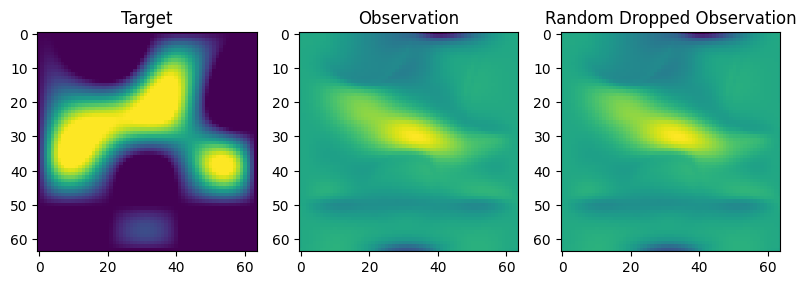

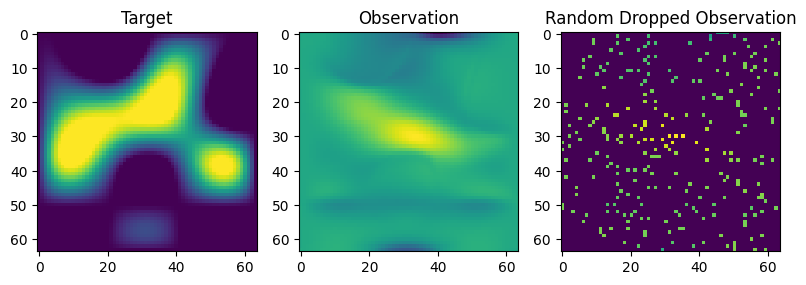

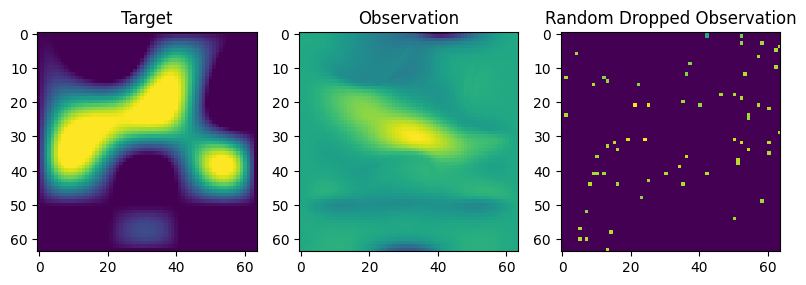

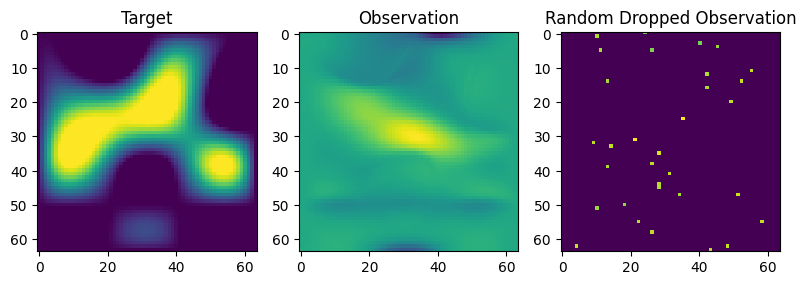

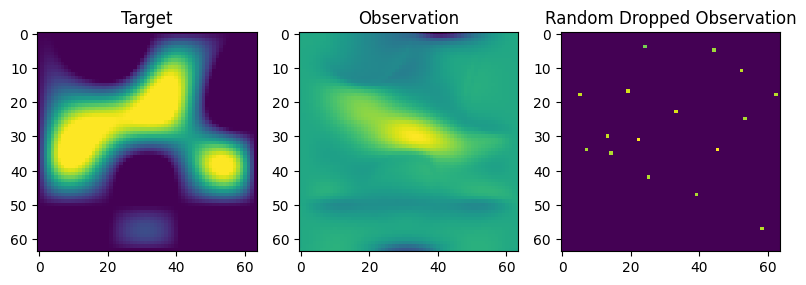

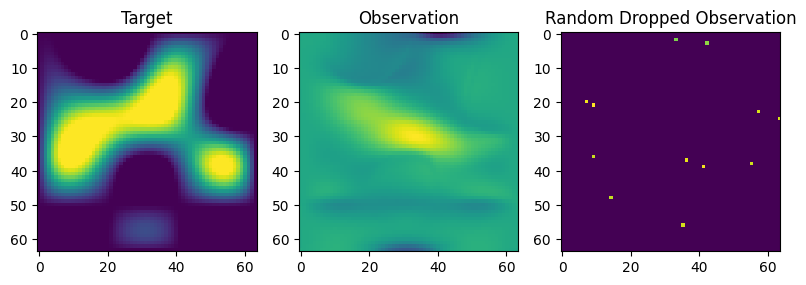

In [5]:
pis_pred = {}

for obs_count in tqdm(range(len(obs_sample))):
    if obs_sample[obs_count] == 4096:
        model, certainty_param = sampler_checkpoint_load(model_dir, 1, obs_sample[obs_count], "closest", device)
    else:
        model, certainty_param = sampler_checkpoint_load(model_dir, 2, obs_sample[obs_count], "closest", device)
    target, obs, drop_obs,_,_,_ = sampler_test_data_generator(model_dir, 2, obs_sample[obs_count], "closest", device, shuffle=False, position=test_pos)
    
    drop_obs_batch = drop_obs.repeat(sample_times, 1, 1)
    img = model.sample(shape=(sample_times,1,64,64), steps=80, device="cuda", conditions=drop_obs_batch)
    img = img.squeeze(1)
    pis_pred[f"Pred-{obs_sample[obs_count]}"] = img

In [6]:
with h5py.File(output_dir, "w") as f:
    for key_val in pis_pred.keys():
        f.create_dataset(key_val, data = pis_pred[key_val].detach().cpu().numpy())